### CiteSeer Dataset Analysis
Use the classic dataset CiteSeer to ensure the correctness of GCN and other model we implement.

In this file we train the graph data, visualize result , and set proper hyper parameters using cross validation.

In [1]:
from cite_data_process import load_siteseer
import numpy as np
import  scipy.sparse as sp

%reload_ext autoreload
%autoreload 2

adj, features, labels, train_masks, val_masks, test_mask = load_siteseer("citeseer")
print("Citeseer data set:\nAdjacency matrix is sparse: ", sp.issparse(adj))
print("All labels are one hot encoding: ", labels[0])
print("Each node has high dimentional feature: ", features.shape[1])
print("Total number of nodes: ", adj.shape[0])
print("Number of training nodes: ", train_masks[0].sum())
print("Number of validation nodes: ", val_masks[0].sum())
print("Number of testing nodes: ", test_mask.sum())

# convert labels from one-hot encoding to integer
class_num = labels.shape[1]
labels = np.argmax(labels, axis=1)

Citeseer data set:
Adjacency matrix is sparse:  True
All labels are one hot encoding:  [0. 0. 0. 1. 0. 0.]
Each node has high dimentional feature:  3703
Total number of nodes:  3327
Number of training nodes:  496
Number of validation nodes:  124
Number of testing nodes:  1000


In [9]:
# now try to train GCN model
from train import train_base
import optuna
from sklearn.model_selection import KFold

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-4, log=True)
    self_importance = trial.suggest_float('self_importance', 0.1, 2.0)
    hidden_units = trial.suggest_int('hidden_units', 8, 64)
    layer_dims = [features.shape[1], hidden_units, class_num]
    
    # KFold Cross Validation
    # kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    val_acc_list = []
    
    for train_mask, val_mask in zip(train_masks, val_masks):
        # Train the model
        model, _,acc_list, loss_list,_ = train_base(
            layer_dims=layer_dims,
            data=(adj, features, labels, train_mask, val_mask),
            dropout_rate=dropout_rate,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            self_importance=self_importance,
            epoch_num=200,
            verbose=False
        )
        
        # Use the validation accuracy for this fold
        val_acc = acc_list[-1] #acc_list的最后一个
        val_acc_list.append(val_acc.cpu())
    # Return the mean validation accuracy across all folds
    mean_val_acc = np.mean(val_acc_list)
    
    return 1.0 - mean_val_acc  # We want to maximize accuracy, so minimize 1 - accuracy

# Create the Optuna study and start optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)  # You can adjust the number of trials

# Print the best hyperparameters
print("Best hyperparameters: ", study.best_params)


[I 2024-07-14 15:27:10,028] A new study created in memory with name: no-name-75f1e734-5633-461c-9efc-45ae9afacb18
[I 2024-07-14 15:27:22,782] Trial 0 finished with value: 0.35483866930007935 and parameters: {'dropout_rate': 0.4366832775715653, 'learning_rate': 0.00018673960658628882, 'weight_decay': 8.447080383067379e-06, 'self_importance': 0.33943249390707764, 'hidden_units': 37}. Best is trial 0 with value: 0.35483866930007935.
[I 2024-07-14 15:27:37,512] Trial 1 finished with value: 0.346774160861969 and parameters: {'dropout_rate': 0.012790340994198013, 'learning_rate': 0.00013852508620609122, 'weight_decay': 2.6885731507047672e-05, 'self_importance': 0.13225651380089196, 'hidden_units': 63}. Best is trial 1 with value: 0.346774160861969.
[I 2024-07-14 15:27:50,241] Trial 2 finished with value: 0.2564516067504883 and parameters: {'dropout_rate': 0.0033383544733568415, 'learning_rate': 0.009095490739616947, 'weight_decay': 5.258775336322813e-05, 'self_importance': 0.7023892396788703

Best hyperparameters:  {'dropout_rate': 0.18793196795151712, 'learning_rate': 0.0047015094408114294, 'weight_decay': 9.681581942149722e-05, 'self_importance': 0.8921418473409928, 'hidden_units': 22}


In [2]:
from train import train_base
layer_dims = [features.shape[1] , 22 ,class_num]
# the first layer will be big like 3703 neuron with 3703*F weight
# here use whole trainning set and test set.
base_model, train_acc_list,test_acc_list, loss_list,predict_result = train_base(
    layer_dims=layer_dims,
    data=(adj, features, labels, train_masks[0] | val_masks[0] , test_mask),
    dropout_rate=0.18793196795151712,
    learning_rate= 0.0047015094408114294,
    weight_decay=  9.681581942149722e-05,
    self_importance= 0.8921418473409928,
    epoch_num = 200
)

print("final accuracy:",test_acc_list[-1],"and final loss:",loss_list[-1])

Using device: cuda 
layer_dims: [3703, 22, 6], 
dropout_rate: 0.18793196795151712, 
learning_rate: 0.0047015094408114294, 
weight_decay: 9.681581942149722e-05, 
epoch_num: 200, 
self_importance: 0.8921418473409928, 
laplace_norm: True
Epoch: 0, Loss: 1.7960, Train Set Acc: 0.5629, Validate Set Acc: 0.4520
Epoch: 1, Loss: 1.7940, Train Set Acc: 0.7194, Validate Set Acc: 0.5710
Epoch: 2, Loss: 1.7920, Train Set Acc: 0.7516, Validate Set Acc: 0.6330
Epoch: 3, Loss: 1.7900, Train Set Acc: 0.7694, Validate Set Acc: 0.6470
Epoch: 4, Loss: 1.7880, Train Set Acc: 0.7823, Validate Set Acc: 0.6830
Epoch: 5, Loss: 1.7861, Train Set Acc: 0.7919, Validate Set Acc: 0.6840
Epoch: 6, Loss: 1.7841, Train Set Acc: 0.7726, Validate Set Acc: 0.6780
Epoch: 7, Loss: 1.7825, Train Set Acc: 0.7903, Validate Set Acc: 0.6680
Epoch: 8, Loss: 1.7806, Train Set Acc: 0.8065, Validate Set Acc: 0.6880
Epoch: 9, Loss: 1.7788, Train Set Acc: 0.8016, Validate Set Acc: 0.6820
Epoch: 10, Loss: 1.7769, Train Set Acc: 0.808

In [10]:
import matplotlib.pyplot as plt

# 绘制验证准确率曲线
def plot_acc_loss(test_acc_list, train_acc_list, loss_list,two_graph=True):
    
    if two_graph:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
    else:
        plt.figure(figsize=(6, 5))
    plt.plot(test_acc_list, label='Test Accuracy')
    plt.plot(train_acc_list, label='Train Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend() #加图例

    # 绘制损失值曲线
    if two_graph:
        plt.subplot(1, 2, 2)
        plt.plot(loss_list, label='Training Loss', color='orange')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss over Epochs')
        plt.legend()

    plt.tight_layout() #调整子图布局
    plt.show()


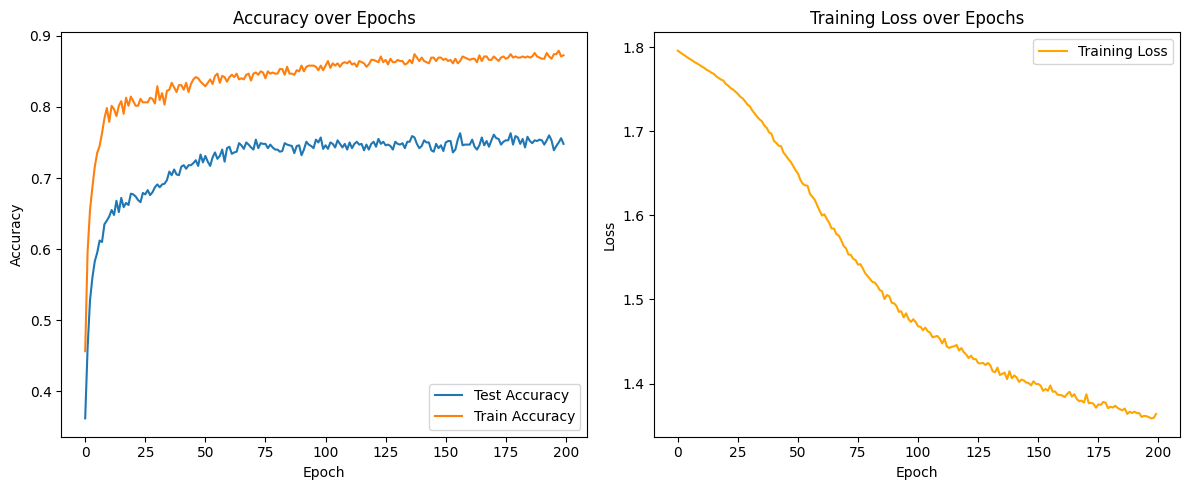

In [11]:
plot_acc_loss(test_acc_list, train_acc_list, loss_list)

### Classification Visualization

Here visualize the classify result by compress embedding feature to 2-dimentional space, and plotting the node with different color to show how well the GCN classifier is comparing to the ground truth.

In [21]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

# convert feature to dense matrix
def embedding_to_2d(features):
    node_embeddings = features.toarray()

    # Use t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, random_state=0)
    node_embeddings_2d = tsne.fit_transform(node_embeddings)

    # Optionally, use PCA before t-SNE for better results
    pca = PCA(n_components=50)
    node_embeddings_pca = pca.fit_transform(node_embeddings)
    node_embeddings_2d = tsne.fit_transform(node_embeddings_pca)
    return node_embeddings_2d

def plot_cluster(node_embeddings_2d,labels):
    # Get cluster labels (assuming you have them from a clustering algorithm)
    cluster_labels = labels

    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("hsv", len(set(cluster_labels)))  # Choose a color palette
    sns.scatterplot(x=node_embeddings_2d[:, 0], y=node_embeddings_2d[:, 1], hue=cluster_labels, palette=palette, 
        legend=False,)
    # plt.title('t-SNE Visualization of Classification in Citeseer()')
    plt.show()

node_embeddings_2d = None

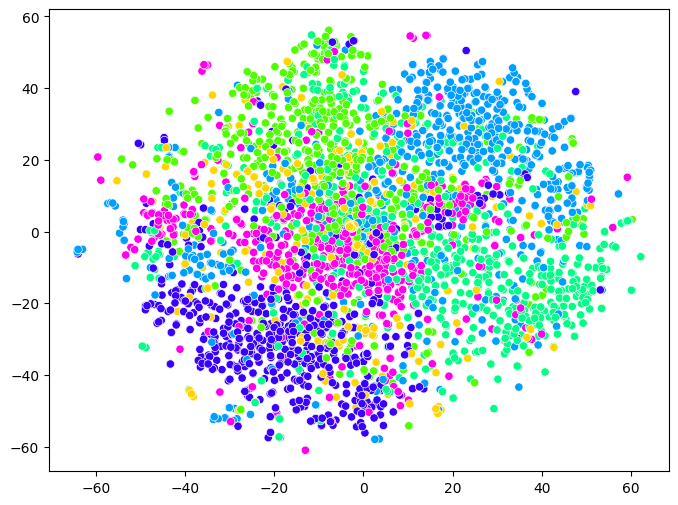

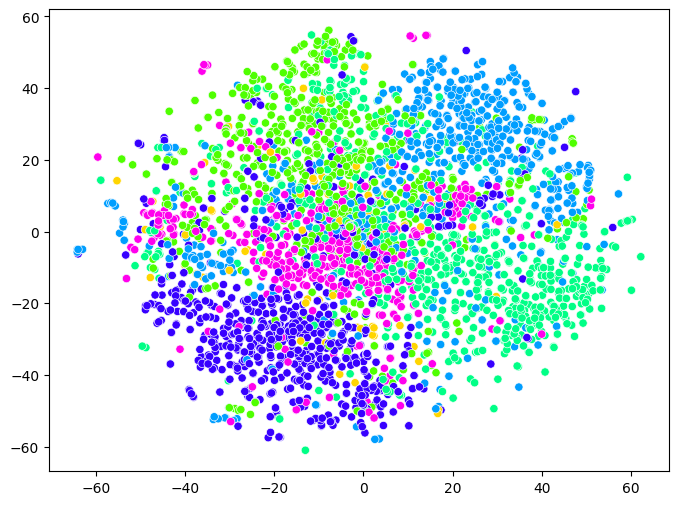

In [22]:
# node_embeddings_2d = embedding_to_2d(features)
if(node_embeddings_2d == None):
    node_embeddings_2d = embedding_to_2d(features)
plot_cluster(node_embeddings_2d,labels)
plot_cluster(node_embeddings_2d,predict_result)

final accuracy: 0.7189999222755432 and final loss: 1.1337232220970317


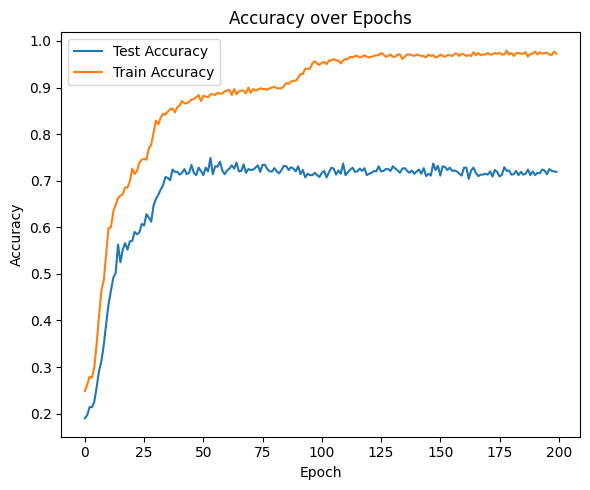

In [33]:
# now add FC_layer and train again
from train import train_fc
layer_dims = [features.shape[1], 80, 22]
fc_dims = [22, class_num]

fc_model, train_acc_list,test_acc_list, loss_list,predict_result = train_fc(
    layer_dims=layer_dims,
    fc_dims = fc_dims,
    data=(adj, features, labels, train_masks[0] | val_masks[0] , test_mask),
    dropout_rate = 0.18793196795151712,
    learning_rate = 0.0047015094408114294,
    weight_decay =  9.681581942149722e-05,
    self_importance = 0.8921418473409928,
    epoch_num = 200,
    verbose = False
)

print("final accuracy:",test_acc_list[-1],"and final loss:",loss_list[-1])

plot_acc_loss(test_acc_list, train_acc_list, loss_list, False)

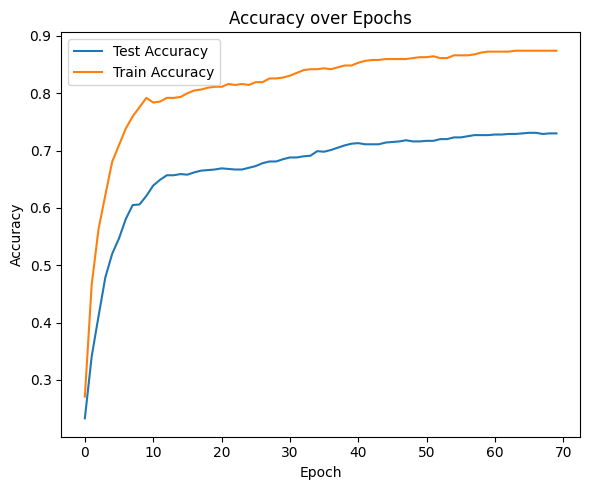

In [11]:
# now use SGC and train again
from train import train_sgc
layer_dims = [features.shape[1], class_num]
sgc_model, train_acc_list,test_acc_list, loss_list ,predict_result = train_sgc(
    layer_dims=layer_dims,
    data=(adj, features, labels, train_masks[0] | val_masks[0] , test_mask),
    degree = 6,
    learning_rate= 0.001,
    weight_decay=  5e-4,
    self_importance= 1,
    epoch_num = 70,
    verbose = False
)

plot_acc_loss(test_acc_list, train_acc_list, loss_list, False)